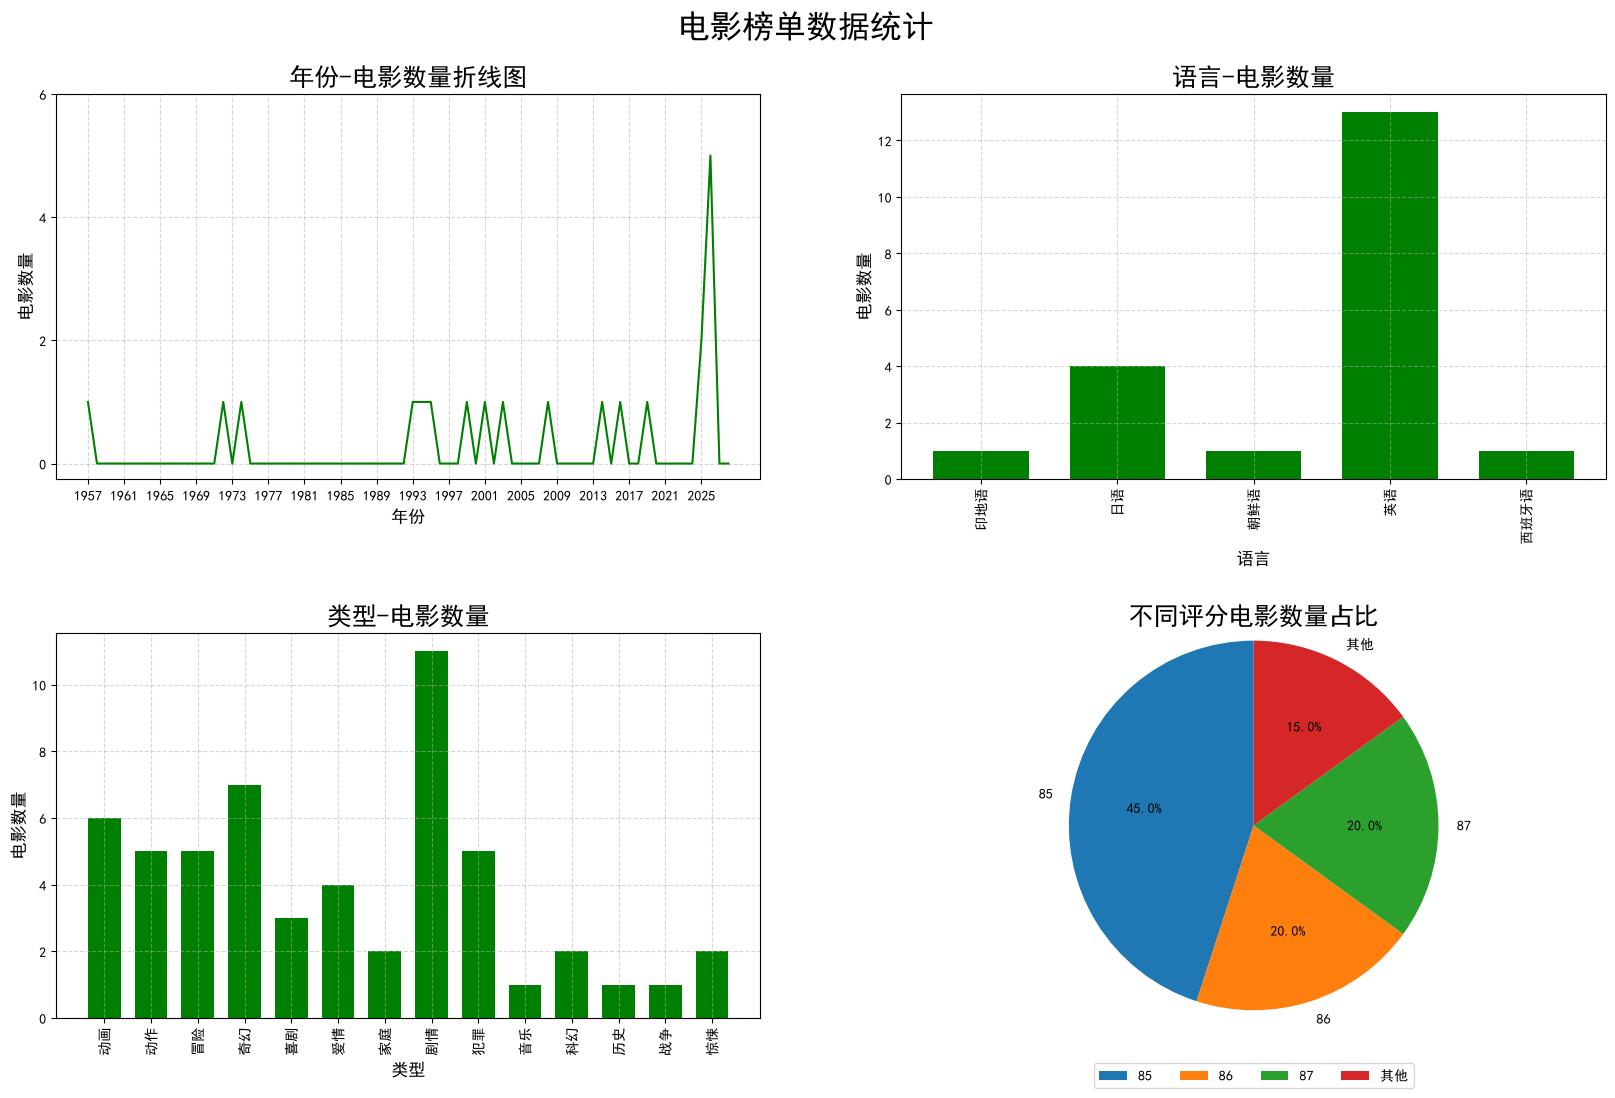

In [40]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize


plt.rcParams['font.sans-serif']=['SimHei']#设置中文以黑体输出

#创建子图
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
fig.suptitle('电影榜单数据统计',fontsize=23,x=0.5,y=0.95)#x,y设置位置
fig.subplots_adjust(hspace=0.4,wspace=0.2)#hspace:垂直间距(行间距),wspace:水平间距(列间距)

#获取子图
axes1: Axes=axes[0][0]
axes2: Axes=axes[0][1]
axes3: Axes=axes[1][0]
axes4: Axes=axes[1][1]

#加载数据
data=pd.read_csv('data/movies_clean.csv',usecols=['电影名','上映年份','上映时间','标签','时长','评分','语言'],dtype={'年份':'Int64'})
#由于 int64整形不支持NaN(若存在一行年份为NAN,则整体类型自动转为float),而Int64支持,float64支持,故加载数据直接指定年份为Int64类型


#绘制年份-电影数量折线图

#1.获取数据
df1=data.groupby('上映年份')['电影名'].count()#返回分组的dataframe

#2.xy值准备
min_year=df1.index.min()#获取索引不用加括号
max_year=df1.index.max()
x=[ i for i in range(min_year,max_year+3)]
#遍历x,若df1存在x对应值,则直接获取;否则填充0;
y=[ int(df1.get(i,0)) for i in x]

#3.绘制图
axes1.plot(x,y,color='green')
axes1.set_title('年份-电影数量折线图',fontsize=18)
axes1.set_xlabel('年份',fontsize=12)
axes1.set_ylabel('电影数量',fontsize=12)

axes1.set_xticks(x[::4])
y_ticks=[ i for i in range(0,7,2)]
axes1.set_yticks(y_ticks)
axes1.grid(linestyle='--',alpha=0.5)


#绘制语言-电影数量柱状图
#1.获取数据
df2=data.groupby('语言')['电影名'].count()

#2.xy值准备
x=df2.index.tolist()
y=df2.values.tolist()

#3.绘制
axes2.bar(x,y,color='g',width=0.7)
axes2.set_title('语言-电影数量',fontsize=18)
axes2.set_xlabel('语言',fontsize=12)
axes2.set_ylabel('电影数量',fontsize=12)
axes2.grid(linestyle='--',alpha=0.5)
axes2.tick_params(axis='x',rotation=90)#调整x


#统计不同类型的电影数量:每个电影可能属于多个类型
#1.统计数量
type_count={}
for types in data['标签'].str.split(','):#循环每行数据
    for type in types:#循环每个类型
        if type in type_count:
            type_count[type]+=1
        else:
            type_count[type]=1
x1=list(type_count.keys())
y1=list(type_count.values())

#2.绘制图表
axes3.bar(x1,y1,color='g',width=0.7)
axes3.set_title('类型-电影数量',fontsize=18)
axes3.set_xlabel('类型',fontsize=12)
axes3.set_ylabel('电影数量',fontsize=12)
axes3.grid(linestyle='--',alpha=0.5)
axes3.tick_params(axis='x',rotation=90)#调整x


#统计不同评分的电影数量占比
#1.获取数据并合并小数据为其他
df3=data.groupby('评分')['电影名'].count()
sum_count=df3.sum()#df3为Series,求和
large_df=df3[df3>sum_count*0.15]#返回series
small_df=df3[~(df3>sum_count*0.15)]
if small_df.shape[0]:#.shape为元组,可以访问
    large_df['其他']=small_df.sum()

#绘制
axes4.pie(large_df.values,labels=large_df.index,autopct='%1.1f%%',startangle=90,radius=1.2)#传入list,series,都可以
#startangle:起始角度,autopct:显示百分比,radius:半径
axes4.set_title('不同评分电影数量占比',fontsize=18)
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.2))


#保存并输出
plt.savefig('data/movies_stats.png')
plt.show()




